In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.set_default_dtype(torch.float64)

# Lennard-Jones target potential
def lj_energy(positions, epsilon=1.0, sigma=1.0, r_cut=3.0):
    """
    positions: [batch, N, 3]
    returns: [batch]
    """
    batch, N, _ = positions.shape

    rij = positions[:, :, None, :] - positions[:, None, :, :]
    r = torch.linalg.norm(rij + torch.eye(N)[None, :, :, None] * 1e6, dim=-1)

    mask = (r < r_cut) & (~torch.eye(N, dtype=torch.bool)[None, :, :])

    sr6 = (sigma / r) ** 6
    sr12 = sr6 ** 2
    v = 4 * epsilon * (sr12 - sr6)

    v = torch.where(mask, v, torch.zeros_like(v))

    return 0.5 * v.sum(dim=(1, 2))


def lj_energy_fs(positions, epsilon=1.0, sigma=1.0, r_cut=3.0):
    """
    Force-shifted Lennard-Jones energy.

    positions: [batch, N, 3]
    returns: [batch]
    """
    batch, N, _ = positions.shape
    device = positions.device

    rij = positions[:, :, None, :] - positions[:, None, :, :]
    r = torch.linalg.norm(rij, dim=-1)

    eye = torch.eye(N, device=device, dtype=torch.bool)

    r = torch.where(
        eye[None, :, :],
        torch.full_like(r, r_cut + 1.0),
        r
    )

    r_safe = torch.clamp(r, min=1.0e-8)

    sr6 = (sigma / r_safe) ** 6
    sr12 = sr6 ** 2

    V = 4.0 * epsilon * (sr12 - sr6)

    sr6_c = (sigma / r_cut) ** 6
    sr12_c = sr6_c ** 2
    V_c = 4.0 * epsilon * (sr12_c - sr6_c)

    dVdr_c = 4.0 * epsilon * (
        -12.0 * sigma**12 / r_cut**13
        + 6.0 * sigma**6 / r_cut**7
    )

    V_fs = V - V_c - (r_safe - r_cut) * dVdr_c

    mask = (r < r_cut) & (~eye[None, :, :])

    V_fs = torch.where(mask, V_fs, torch.zeros_like(V_fs))

    return 0.5 * V_fs.sum(dim=(1, 2))


def generate_pair_batch(batch_size=512, r_min=0.90, r_cut=3.0):
    """
    Generate two-particle LJ configurations.

    Half of the samples are near the repulsive/attractive region,
    half are in the long-range tail.
    """
    n1 = batch_size // 2
    n2 = batch_size - n1

    r1 = r_min + (1.5 - r_min) * torch.rand(n1)
    r2 = 1.5 + (r_cut - 1.5) * torch.rand(n2)

    r = torch.cat([r1, r2], dim=0)

    perm = torch.randperm(batch_size)
    r = r[perm]

    positions = torch.zeros(batch_size, 2, 3)
    positions[:, 1, 0] = r

    return positions


def cutoff(r, r_cut):
    fc = 0.5 * (torch.cos(torch.pi * r / r_cut) + 1.0)
    return torch.where(r < r_cut, fc, torch.zeros_like(r))


# ANI-like radial AEV
class RadialAEV(nn.Module):
    def __init__(self, r_cut=3.0, eta=16.0, n_radial=32):
        super().__init__()
        self.r_cut = r_cut
        self.eta = eta
        self.register_buffer("Rs", torch.linspace(0.7, r_cut, n_radial))

    def forward(self, positions):
        """
        positions: [batch, N, 3]
        returns: [batch, N, n_radial]
        """
        batch, N, _ = positions.shape
        device = positions.device
        dtype = positions.dtype

        rij = positions[:, :, None, :] - positions[:, None, :, :]
        r = torch.linalg.norm(rij, dim=-1)

        eye = torch.eye(N, device=device, dtype=torch.bool)

        r = torch.where(
            eye[None, :, :],
            torch.full_like(r, 1.0e6),
            r
        )

        fc = cutoff(r, self.r_cut)

        Rs = self.Rs.to(device=device, dtype=dtype)

        radial = torch.exp(
            -self.eta * (r[..., None] - Rs) ** 2
        ) * fc[..., None]

        not_self = (~eye)[None, :, :, None].to(dtype)

        radial = radial * not_self

        return radial.sum(dim=2)


# Atomic neural network
class ANILJ(nn.Module):
    
    def __init__(self, n_radial=32, n_hidden=64):
        super().__init__()
        self.aev = RadialAEV(n_radial=n_radial)

        self.atomic_net = nn.Sequential(
            nn.Linear(n_radial, n_hidden),
            nn.SiLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.SiLU(),
            nn.Linear(n_hidden, 1)
        )

    def forward(self, positions):
        """
        positions: [batch, N, 3]
        returns total energy: [batch]
        """
        G = self.aev(positions)
        atomic_energies = self.atomic_net(G).squeeze(-1)
        return atomic_energies.sum(dim=1)


def generate_batch(batch_size=128, N=8, box=4.0):
    positions = box * torch.rand(batch_size, N, 3)
    return positions


import torch.nn.functional as F

model = ANILJ(n_radial=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-4)

force_weight = 0.01

for step in range(10000):
    pos_base = generate_pair_batch(
        batch_size=512,
        r_min=0.90,
        r_cut=3.0
    ).detach()

    target_pos = pos_base.clone().detach().requires_grad_(True)

    target_E_graph = lj_energy_fs(target_pos)

    target_F = -torch.autograd.grad(
        target_E_graph.sum(),
        target_pos,
        create_graph=False
    )[0]

    target_E = target_E_graph.detach()
    target_F = target_F.detach()

    pos_energy = pos_base.clone().detach()

    pred_E_energy = model(pos_energy)

    energy_loss = F.smooth_l1_loss(
        pred_E_energy / 2.0,
        target_E / 2.0,
        beta=0.05
    )

    pos_force = pos_base.clone().detach().requires_grad_(True)

    pred_E_force = model(pos_force)

    pred_F = -torch.autograd.grad(
        pred_E_force.sum(),
        pos_force,
        create_graph=True
    )[0]

    force_loss = F.smooth_l1_loss(
        pred_F,
        target_F,
        beta=0.05
    )

    loss = energy_loss + force_weight * force_loss

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)

    optimizer.step()

    if step % 500 == 0:
        print(
            step,
            "loss =", loss.item(),
            "energy_loss =", energy_loss.item(),
            "force_loss =", force_loss.item()
        )

/home/tigran/.local/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


0 loss = 0.22089438220090607 energy_loss = 0.20131571981165813 force_loss = 1.9578662389247945
500 loss = 0.09053831647589267 energy_loss = 0.07501958611807753 force_loss = 1.5518730357815127
1000 loss = 0.06767098835189694 energy_loss = 0.05156780934179651 force_loss = 1.610317901010043
1500 loss = 0.03194431261625384 energy_loss = 0.022710011869848074 force_loss = 0.923430074640577
2000 loss = 0.010668117715705104 energy_loss = 0.006125460036764277 force_loss = 0.45426576789408285
2500 loss = 0.00207764994426302 energy_loss = 0.0007086027474369058 force_loss = 0.13690471968261142
3000 loss = 0.0022869455420415786 energy_loss = 0.0008080869321724528 force_loss = 0.1478858609869126
3500 loss = 0.0007985825644687184 energy_loss = 0.000247209043131666 force_loss = 0.055137352133705235
4000 loss = 0.0006175693757630354 energy_loss = 0.00016233816683468318 force_loss = 0.04552312089283522
4500 loss = 0.0003649891454588881 energy_loss = 3.395895657923804e-05 force_loss = 0.03310301888796501

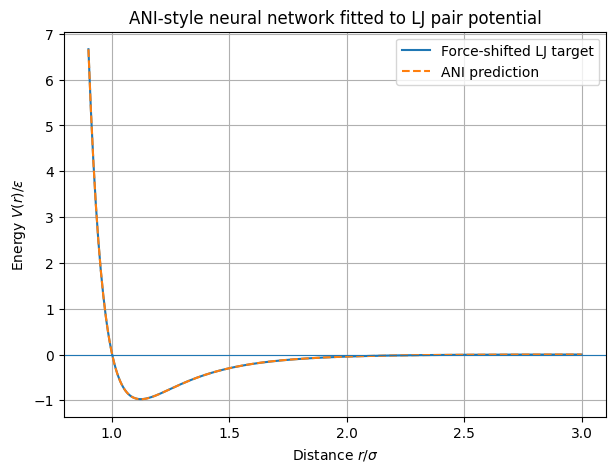

In [ ]:
import matplotlib.pyplot as plt

r_values = torch.linspace(0.90, 3.0, 400)

positions = torch.zeros(len(r_values), 2, 3)
positions[:, 1, 0] = r_values

with torch.no_grad():
    E_lj = lj_energy_fs(positions)
    E_nn = model(positions)

plt.figure(figsize=(7, 5))
plt.plot(r_values.numpy(), E_lj.numpy(), label="Force-shifted LJ target")
plt.plot(r_values.numpy(), E_nn.numpy(), "--", label="ANI prediction")

plt.axhline(0.0, linewidth=0.8)
plt.xlabel(r"Distance $r/\sigma$")
plt.ylabel(r"Energy $V(r)/\epsilon$")
plt.title("ANI-style neural network fitted to LJ pair potential")
plt.legend()
plt.grid(True)
plt.savefig('LJ_ANI.png')